# Experiment: Ridge Transfer Experiment
Cравнивать режимы по `relative Frobenius error`, `cond(P @ A)`, среднему числу итераций `GMRES` и относительной невязке

Контролируемый эксперимент на семействе SPD-матриц: оно остаётся в экосистеме `workbench`, но позволяет увидеть и деградацию zero-shot, и восстановление качества после post training

In [14]:
from __future__ import annotations

from pathlib import Path
import sys

root = Path.cwd().resolve()
if not (root / 'preconditioner').exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from ridge_transfer.ridge_transfer_helpers import (
    TransferExperimentConfig,
    describe_registered_families,
    format_summary_table,
    plot_adaptation_curve,
    plot_per_sample_transfer,
    plot_regime_dashboard,
    register_trained_model,
    run_transfer_experiment,
    summaries_for_report,
)

import matplotlib.pyplot as plt


In [16]:
config = TransferExperimentConfig(
    matrix_size=24,
    ridge_reg=1e-3,
    base_train_samples=72,
    base_val_samples=24,
    shifted_eval_samples=24,
    fine_tune_sizes=(0, 1, 2, 4, 6, 8, 12),
    showcase_fine_tune_size=4,
)
bundle = run_transfer_experiment(config)
core_summaries = summaries_for_report(bundle)
print(format_summary_table(core_summaries))

Regime                   Split    Adapt    Rel.Fro   cond(PA)    GMRES     None     Diag     Residual
-----------------------------------------------------------------------------------------------------
Base validation          base         0     0.0045     1.0079    3.375    9.500    9.333    1.536e-09
Shifted zero-shot        shifted      0     0.0666     1.1046    5.500   12.417   12.167    1.933e-09
Shifted + fine-tune (4)  shifted      4     0.0138     1.0214    4.000   12.417   12.167    1.161e-09


## Как устроены датасеты

В эксперименте используются два близких семейства матриц с одной и той же фиксированной ортогональной базой:
- `Base Local SPD` обучает и валидирует ridge в привычном распределении;
- `Shifted Local SPD` немного сдвигает диапазоны спектральных параметров (`rho`, `shift`, `wobble`), то есть меняет матрицы не радикально, а локально.

Это и есть контролируемая версия вопроса: насколько текущий обучаемый предобуславливатель переносится на "почти те же" матрицы без переобучения и сколько новых примеров нужно, чтобы быстро адаптироваться.
        


In [19]:
print('Размер матрицы:', bundle.config.matrix_size)
print('Train | base-val | shifted-eval:', len(bundle.train_matrices), len(bundle.base_val_matrices), len(bundle.shifted_eval_matrices))
print('Ridge regularization:', bundle.config.ridge_reg)
print()
print(describe_registered_families(bundle))
print()
print('Base ranges:')
print('  rho   =', bundle.config.base_rho_range)
print('  shift =', bundle.config.base_shift_range)
print('  wobble=', bundle.config.base_wobble_range)
print('Shifted ranges:')
print('  rho   =', bundle.config.shifted_rho_range)
print('  shift =', bundle.config.shifted_shift_range)
print('  wobble=', bundle.config.shifted_wobble_range)

Размер матрицы: 24
Train | base-val | shifted-eval: 72 24 24
Ridge regularization: 0.001

- Base Local SPD: Local SPD family with fixed eigenbasis; rho in (0.1, 0.3), shift in (0.05, 0.2), wobble in (0.0, 0.06)
- Shifted Local SPD: Local SPD family with fixed eigenbasis; rho in (0.32, 0.44), shift in (0.26, 0.36), wobble in (0.08, 0.14)

Base ranges:
  rho   = (0.1, 0.3)
  shift = (0.05, 0.2)
  wobble= (0.0, 0.06)
Shifted ranges:
  rho   = (0.32, 0.44)
  shift = (0.26, 0.36)
  wobble= (0.08, 0.14)


## Та же ridge-модель внутри `workbench`

Ниже одна и та же обученная ridge-модель регистрируется в `PreconditionerWorkbenchV2` как новый предобуславливатель. Так видно, что эксперимент не живёт отдельно от архитектуры репозитория, а встраивается в основной API.
        


In [21]:
register_trained_model(bundle.workbench, bundle.base_model, name='RidgeBaseModel')
register_trained_model(bundle.workbench, bundle.showcase_model, name='RidgeFineTuned')

sample_matrix = bundle.shifted_eval_matrices[0]
base_eval = bundle.workbench.evaluate_matrix(
    sample_matrix,
    preconditioner='RidgeBaseModel',
    solver='GMRES',
    signed_kappa=False,
)
tuned_eval = bundle.workbench.evaluate_matrix(
    sample_matrix,
    preconditioner='RidgeFineTuned',
    solver='GMRES',
    signed_kappa=False,
)
print(base_eval)
print(tuned_eval)

MatrixEvaluationResult(preconditioner='RidgeBaseModel', solver='GMRES', kappa=2.449489041585282, kappa_pre=1.0879001895645848, delta_kappa=-1.3615888520206973, ratio_kappa=0.44413351972397797, converged=True, n_iter=5, residual=1.898744034954385e-08, preconditioner_time=0.0001559590018587187, kappa_eval_time=0.00021716599439969286, solve_time=0.0010452919959789142, total_time=0.0014184169922373258)
MatrixEvaluationResult(preconditioner='RidgeFineTuned', solver='GMRES', kappa=2.449489041585282, kappa_pre=1.020361825439902, delta_kappa=-1.42912721614538, ratio_kappa=0.41656109013638826, converged=True, n_iter=4, residual=3.2695596508653533e-09, preconditioner_time=0.0001413749996572733, kappa_eval_time=0.0001777500001480803, solve_time=0.001159416999144014, total_time=0.0014785419989493676)


## Графики: базовая валидация, zero-shot перенос и микро-дообучение
- base-validation показывает, насколько ridge хорошо выучила исходное распределение;
- shifted zero-shot показывает, как падает качество без адаптации;
- `fine-tune (4)` показывает, что даже 4 новых матрицы почти возвращают модель в рабочий режим.

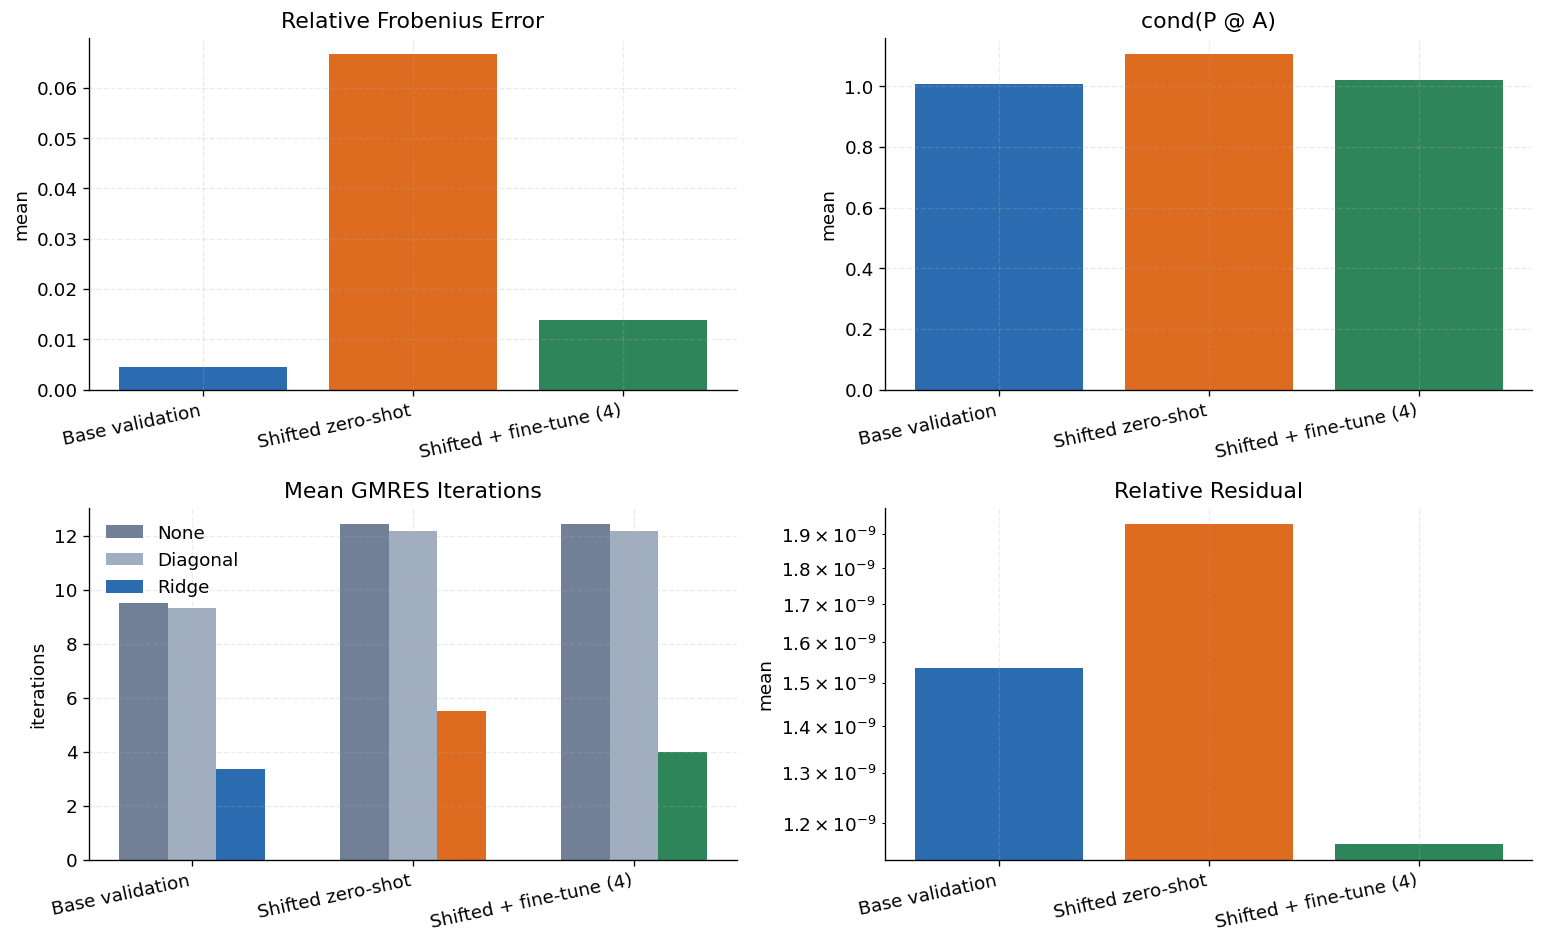

In [22]:
fig_dashboard, _ = plot_regime_dashboard(core_summaries)
plt.show()

## Кривая адаптации
Модель не имеет `partial_fit`, дообучение реализовано как быстрый refit той же ridge-конфигурации на `base train + k shifted samples`

Regime                   Split    Adapt    Rel.Fro   cond(PA)    GMRES     None     Diag     Residual
-----------------------------------------------------------------------------------------------------
Shifted zero-shot        shifted      0     0.0666     1.1046    5.500   12.417   12.167    1.933e-09
Shifted + fine-tune (1)  shifted      1     0.0299     1.0396    4.375   12.417   12.167    3.062e-09
Shifted + fine-tune (2)  shifted      2     0.0193     1.0283    4.000   12.417   12.167    2.922e-09
Shifted + fine-tune (4)  shifted      4     0.0138     1.0214    4.000   12.417   12.167    1.161e-09
Shifted + fine-tune (6)  shifted      6     0.0118     1.0190    4.000   12.417   12.167    7.968e-10
Shifted + fine-tune (8)  shifted      8     0.0115     1.0183    3.958   12.417   12.167    1.161e-09
Shifted + fine-tune (12) shifted     12     0.0094     1.0153    3.958   12.417   12.167    6.408e-10



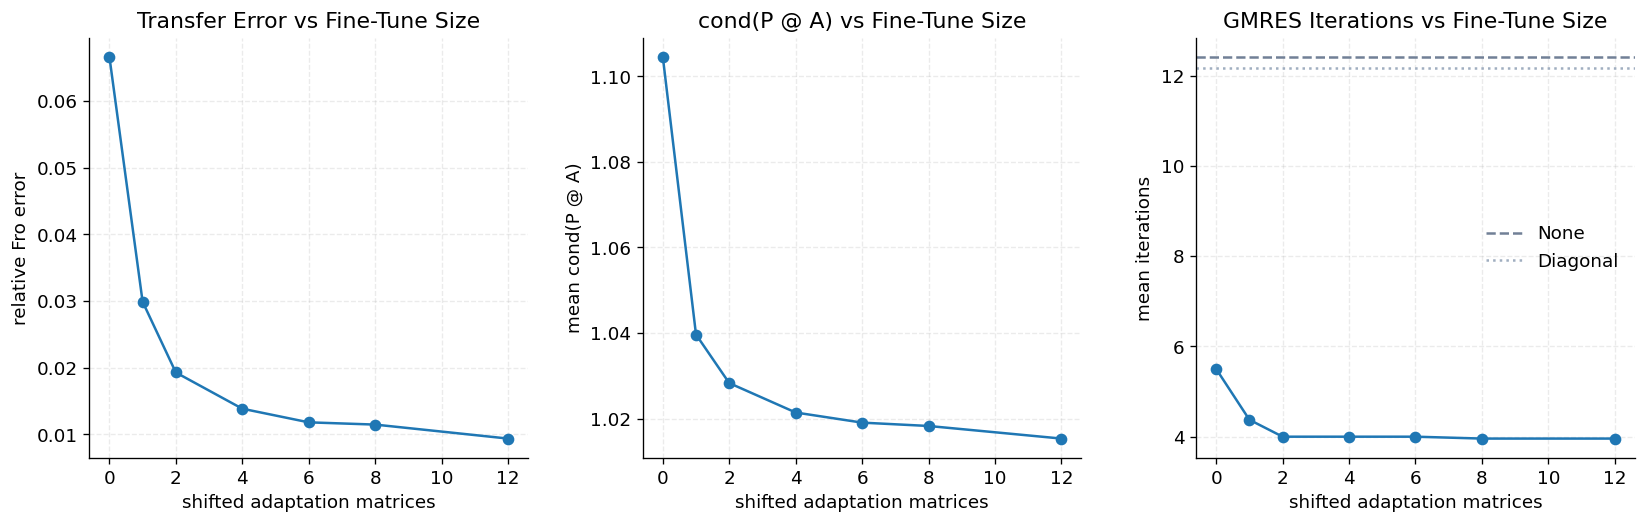

In [23]:
print(format_summary_table(bundle.adaptation_summaries))
print()
fig_curve, _ = plot_adaptation_curve(bundle.adaptation_summaries)
plt.show()

## shifted zero-shot vs fine-tune
Сэмплы ниже отсортированы по zero-shot сложности


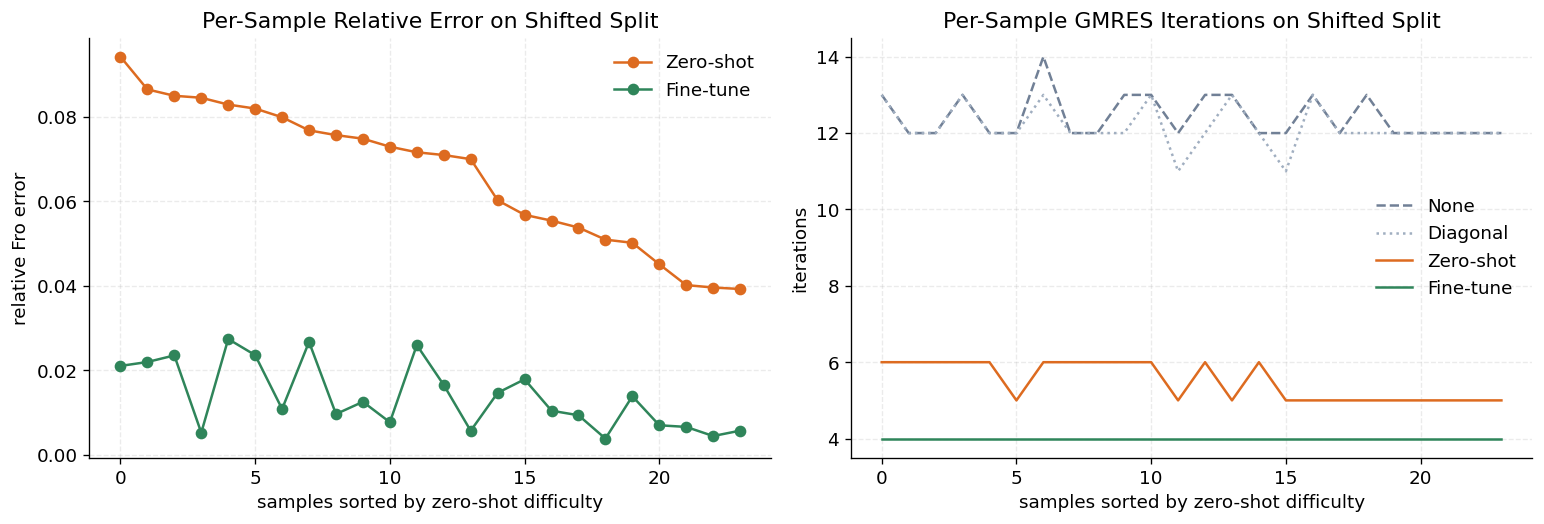

In [24]:
fig_transfer, _ = plot_per_sample_transfer(bundle.zero_shot_records, bundle.showcase_records)
plt.show()

In [13]:
base = bundle.base_summary
zero = bundle.zero_shot_summary
tuned = bundle.showcase_summary
print(f'Base validation: rel_fro={base.relative_fro_error_mean:.4f}, cond(PA)={base.preconditioned_kappa_mean:.4f}, GMRES={base.gmres_iterations_mean:.3f}')
print(f'Shifted zero-shot: rel_fro={zero.relative_fro_error_mean:.4f}, cond(PA)={zero.preconditioned_kappa_mean:.4f}, GMRES={zero.gmres_iterations_mean:.3f}')
print(f'Shifted + fine-tune ({tuned.adaptation_samples}): rel_fro={tuned.relative_fro_error_mean:.4f}, cond(PA)={tuned.preconditioned_kappa_mean:.4f}, GMRES={tuned.gmres_iterations_mean:.3f}')

Base validation: rel_fro=0.0045, cond(PA)=1.0079, GMRES=3.375
Shifted zero-shot: rel_fro=0.0666, cond(PA)=1.1046, GMRES=5.500
Shifted + fine-tune (4): rel_fro=0.0138, cond(PA)=1.0214, GMRES=4.000
